In [31]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
DATA_DIR = Path.cwd().parent / "data" / "raw"

In [4]:
train_values = pd.read_csv(DATA_DIR / "train_values.csv", index_col="sequence_id")
train_labels = pd.read_csv(DATA_DIR / "train_labels.csv", index_col="sequence_id")

In [5]:
train_values.head()

,sequence,bacterial_resistance_ampicillin,bacterial_resistance_chloramphenicol,bacterial_resistance_kanamycin,bacterial_resistance_other,bacterial_resistance_spectinomycin,copy_number_high_copy,copy_number_low_copy,copy_number_unknown,growth_strain_ccdb_survival,growth_strain_dh10b,growth_strain_dh5alpha,growth_strain_neb_stable,growth_strain_other,growth_strain_stbl3,growth_strain_top10,growth_strain_xl1_blue,growth_temp_30,growth_temp_37,growth_temp_other,selectable_markers_blasticidin,selectable_markers_his3,selectable_markers_hygromycin,selectable_markers_leu2,selectable_markers_neomycin,selectable_markers_other,selectable_markers_puromycin,selectable_markers_trp1,selectable_markers_ura3,selectable_markers_zeocin,species_budding_yeast,species_fly,species_human,species_mouse,species_mustard_weed,species_nematode,species_other,species_rat,species_synthetic,species_zebrafish
sequence_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
9ZIMC,CATGCATTAGTTATTAATAGTAATCAATTACGGGGTCATTAGTTCA...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5SAQC,GCTGGATGGTTTGGGACATGTGCAGCCCCGTCTCTGTATGGAGTGA...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
E7QRO,NNCCGGGCTGTAGCTACACAGGGCGGAGATGAGAGCCCTACGAAAG...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
CT5FP,GCGGAGATGAAGAGCCCTACGAAAGCTGAGCCTGCGACTCCCGCAG...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7PTD8,CGCGCATTACTTCACATGGTCCTCAAGGGTAACATGAAAGTGATCC...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
train_labels.sum()

00Q4V31T     17.0
012VT4JK     41.0
028IO5W2     14.0
03GRNN7N      4.0
03Y3W51H    345.0
            ...  
ZU75P59K     67.0
ZUI6TDWV      9.0
ZWFD8OHC     49.0
ZX06ZDZN      9.0
ZZJVE4HO    193.0
Length: 1314, dtype: float64

In [7]:
train_values.dtypes


sequence                                 object
bacterial_resistance_ampicillin         float64
bacterial_resistance_chloramphenicol    float64
bacterial_resistance_kanamycin          float64
bacterial_resistance_other              float64
bacterial_resistance_spectinomycin      float64
copy_number_high_copy                   float64
copy_number_low_copy                    float64
copy_number_unknown                     float64
growth_strain_ccdb_survival             float64
growth_strain_dh10b                     float64
growth_strain_dh5alpha                  float64
growth_strain_neb_stable                float64
growth_strain_other                     float64
growth_strain_stbl3                     float64
growth_strain_top10                     float64
growth_strain_xl1_blue                  float64
growth_temp_30                          float64
growth_temp_37                          float64
growth_temp_other                       float64
selectable_markers_blasticidin          

In [8]:
sequence_lengths = train_values.sequence.apply(len)

sequence_lengths.describe()

count    63017.000000
mean      4839.025501
std       3883.148431
min         20.000000
25%        909.000000
50%       4741.000000
75%       7490.000000
max      60099.000000
Name: sequence, dtype: float64

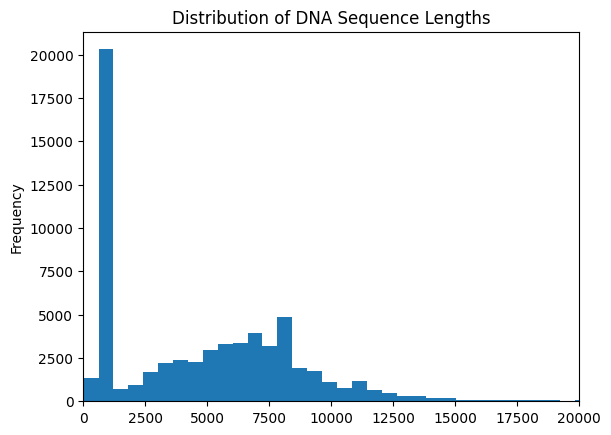

In [9]:
sequence_lengths.plot(
    kind="hist", title="Distribution of DNA Sequence Lengths", bins=100, xlim=(0, 20000)
);  # don't plot super long sequences

In [10]:
train_values.iloc[:, 1:].apply(pd.value_counts)

/var/folders/yj/nqdvf2gs6_z5zyjdgjgm9p9w0000gn/T/ipykernel_49803/4128791272.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  train_values.iloc[:, 1:].apply(pd.value_counts)


,bacterial_resistance_ampicillin,bacterial_resistance_chloramphenicol,bacterial_resistance_kanamycin,bacterial_resistance_other,bacterial_resistance_spectinomycin,copy_number_high_copy,copy_number_low_copy,copy_number_unknown,growth_strain_ccdb_survival,growth_strain_dh10b,growth_strain_dh5alpha,growth_strain_neb_stable,growth_strain_other,growth_strain_stbl3,growth_strain_top10,growth_strain_xl1_blue,growth_temp_30,growth_temp_37,growth_temp_other,selectable_markers_blasticidin,selectable_markers_his3,selectable_markers_hygromycin,selectable_markers_leu2,selectable_markers_neomycin,selectable_markers_other,selectable_markers_puromycin,selectable_markers_trp1,selectable_markers_ura3,selectable_markers_zeocin,species_budding_yeast,species_fly,species_human,species_mouse,species_mustard_weed,species_nematode,species_other,species_rat,species_synthetic,species_zebrafish
0.0,19590,60506,48706,62078,58592,18750,57313,50059,61841,61285,17440,58004,60436,60647,60331,61216,61148,1985,62989,62387,62679,61237,62574,54069,60835,56600,62585,62160,62458,61417,61478,36890,57732,61978,62322,56381,61949,55170,61742
1.0,43427,2511,14311,939,4425,44267,5704,12958,1176,1732,45577,5013,2581,2370,2686,1801,1869,61032,28,630,338,1780,443,8948,2182,6417,432,857,559,1600,1539,26127,5285,1039,695,6636,1068,7847,1275


In [11]:
# get the column with the max value in each row
lab_ids = pd.DataFrame(train_labels.idxmax(axis=1), columns=["lab_id"])
lab_ids.head()

,lab_id
sequence_id,
9ZIMC,RYUA3GVO
5SAQC,RYUA3GVO
E7QRO,RYUA3GVO
CT5FP,RYUA3GVO
7PTD8,RYUA3GVO


In [12]:
lab_ids["lab_id"].value_counts().describe()


count    1314.000000
mean       47.958143
std       262.552258
min         1.000000
25%         9.000000
50%        15.000000
75%        34.000000
max      8286.000000
Name: count, dtype: float64

In [13]:
bases = set("".join(train_values.sequence.values))
bases

{'A', 'C', 'G', 'N', 'T'}

In [14]:
from itertools import permutations

In [15]:
for i in permutations(bases, r=4):
    print(i)

('T', 'N', 'G', 'C')
('T', 'N', 'G', 'A')
('T', 'N', 'C', 'G')
('T', 'N', 'C', 'A')
('T', 'N', 'A', 'G')
('T', 'N', 'A', 'C')
('T', 'G', 'N', 'C')
('T', 'G', 'N', 'A')
('T', 'G', 'C', 'N')
('T', 'G', 'C', 'A')
('T', 'G', 'A', 'N')
('T', 'G', 'A', 'C')
('T', 'C', 'N', 'G')
('T', 'C', 'N', 'A')
('T', 'C', 'G', 'N')
('T', 'C', 'G', 'A')
('T', 'C', 'A', 'N')
('T', 'C', 'A', 'G')
('T', 'A', 'N', 'G')
('T', 'A', 'N', 'C')
('T', 'A', 'G', 'N')
('T', 'A', 'G', 'C')
('T', 'A', 'C', 'N')
('T', 'A', 'C', 'G')
('N', 'T', 'G', 'C')
('N', 'T', 'G', 'A')
('N', 'T', 'C', 'G')
('N', 'T', 'C', 'A')
('N', 'T', 'A', 'G')
('N', 'T', 'A', 'C')
('N', 'G', 'T', 'C')
('N', 'G', 'T', 'A')
('N', 'G', 'C', 'T')
('N', 'G', 'C', 'A')
('N', 'G', 'A', 'T')
('N', 'G', 'A', 'C')
('N', 'C', 'T', 'G')
('N', 'C', 'T', 'A')
('N', 'C', 'G', 'T')
('N', 'C', 'G', 'A')
('N', 'C', 'A', 'T')
('N', 'C', 'A', 'G')
('N', 'A', 'T', 'G')
('N', 'A', 'T', 'C')
('N', 'A', 'G', 'T')
('N', 'A', 'G', 'C')
('N', 'A', 'C', 'T')
('N', 'A', 'C

In [16]:
n = 4
subsequences = ["".join(permutation) for permutation in permutations(bases, r=n)]


In [17]:
print(f"Number of subsequences: {len(subsequences)}")
subsequences[:10]

Number of subsequences: 120


['TNGC',
 'TNGA',
 'TNCG',
 'TNCA',
 'TNAG',
 'TNAC',
 'TGNC',
 'TGNA',
 'TGCN',
 'TGCA']

In [18]:
def get_ngram_features(data, subsequences):
    """Generates counts for each subsequence.

    Args:
        data (DataFrame): The data you want to create features from. Must include a "sequence" column.
        subsequences (list): A list of subsequences to count.

    Returns:
        DataFrame: A DataFrame with one column for each subsequence.
    """
    features = pd.DataFrame(index=data.index)
    for subseq in subsequences:
        features[subseq] = data.sequence.str.count(subseq)
    return features

In [ ]:
# Calculate n-gram features on our training set
ngram_features = get_ngram_features(train_values, subsequences)
ngram_features.head()

In [20]:
all_features = ngram_features.join(train_values.drop("sequence", axis=1))


In [21]:
all_features.head()

,TNGC,TNGA,TNCG,TNCA,TNAG,TNAC,TGNC,TGNA,TGCN,TGCA,TGAN,TGAC,TCNG,TCNA,TCGN,TCGA,TCAN,TCAG,TANG,TANC,TAGN,TAGC,TACN,TACG,NTGC,NTGA,NTCG,NTCA,NTAG,NTAC,NGTC,NGTA,NGCT,NGCA,NGAT,NGAC,NCTG,NCTA,NCGT,NCGA,NCAT,NCAG,NATG,NATC,NAGT,NAGC,NACT,NACG,GTNC,GTNA,GTCN,GTCA,GTAN,GTAC,GNTC,GNTA,GNCT,GNCA,GNAT,GNAC,GCTN,GCTA,GCNT,GCNA,GCAT,GCAN,GATN,GATC,GANT,GANC,GACT,GACN,CTNG,CTNA,CTGN,CTGA,CTAN,CTAG,CNTG,CNTA,CNGT,CNGA,CNAT,CNAG,CGTN,CGTA,CGNT,CGNA,CGAT,CGAN,CATN,CATG,CANT,CANG,CAGT,CAGN,ATNG,ATNC,ATGN,ATGC,ATCN,ATCG,ANTG,ANTC,ANGT,ANGC,ANCT,ANCG,AGTN,AGTC,AGNT,AGNC,AGCT,AGCN,ACTN,ACTG,ACNT,ACNG,ACGT,ACGN,bacterial_resistance_ampicillin,bacterial_resistance_chloramphenicol,bacterial_resistance_kanamycin,bacterial_resistance_other,bacterial_resistance_spectinomycin,copy_number_high_copy,copy_number_low_copy,copy_number_unknown,growth_strain_ccdb_survival,growth_strain_dh10b,growth_strain_dh5alpha,growth_strain_neb_stable,growth_strain_other,growth_strain_stbl3,growth_strain_top10,growth_strain_xl1_blue,growth_temp_30,growth_temp_37,growth_temp_other,selectable_markers_blasticidin,selectable_markers_his3,selectable_markers_hygromycin,selectable_markers_leu2,selectable_markers_neomycin,selectable_markers_other,selectable_markers_puromycin,selectable_markers_trp1,selectable_markers_ura3,selectable_markers_zeocin,species_budding_yeast,species_fly,species_human,species_mouse,species_mustard_weed,species_nematode,species_other,species_rat,species_synthetic,species_zebrafish
sequence_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
9ZIMC,0,0,0,0,0,0,0,0,0,29,0,46,0,0,0,24,0,37,0,0,0,13,0,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28,0,15,0,0,0,0,0,0,0,27,0,0,20,0,0,32,0,0,30,0,0,0,0,44,0,13,0,0,0,0,0,0,0,14,0,0,17,0,0,28,0,0,25,0,0,0,0,30,0,19,0,0,0,0,0,0,0,25,0,0,39,0,0,24,0,0,21,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5SAQC,0,0,0,0,0,0,0,0,0,2,0,6,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,6,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,3,0,0,0,0,2,0,1,0,0,0,0,0,0,0,2,0,0,2,0,0,3,0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
E7QRO,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,3,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,3,0,0,2,0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
CT5FP,0,0,0,0,0,0,0,0,0,5,0,2,0,0,0,3,0,6,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,1,0,0,0,0,0,0,0,3,0,0,3,0,0,7,0,0,3,0,0,0,0,8,0,6,0,0,0,0,0,0,0,1,0,0,0,0,0,3,0,0,3,0,0,0,0,2,0,1,0,0,0,0,0,0,0,6,0,0,2,0,0,3,0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7PTD8,0,1,0,0,0,0,0,0,0,2,0,5,0,0,0,3,0,3,0,0,0,3,0,2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,0,4,0,0,0,0,0,0,0,2,0,0,3,0,0,3,0,0,6,0,0,0,0,4,0,2,0,0,0,0,0,0,0,2,0,0,1,0,0,7,0,1,4,0,0,0,0,6,0,2,0,0,0,1,0,0,0,3,0,0,5,0,0,5,0,0,3,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
def top10_accuracy_scorer(estimator, X, y):
    """A custom scorer that evaluates a model on whether the correct label is in
    the top 10 most probable predictions.

    Args:
        estimator (sklearn estimator): The sklearn model that should be evaluated.
        X (numpy array): The validation data.
        y (numpy array): The ground truth labels.

    Returns:
        float: Accuracy of the model as defined by the proportion of predictions
               in which the correct label was in the top 10. Higher is better.
    """
    # predict the probabilities across all possible labels for rows in our training set
    probas = estimator.predict_proba(X)

    # get the indices for top 10 predictions for each row; these are the last ten in each row
    # Note: We use argpartition, which is O(n), vs argsort, which uses the quicksort algorithm
    # by default and is O(n^2) in the worst case. We can do this because we only need the top ten
    # partitioned, not in sorted order.
    # Documentation: https://numpy.org/doc/1.18/reference/generated/numpy.argpartition.html
    top10_idx = np.argpartition(probas, -10, axis=1)[:, -10:]

    # index into the classes list using the top ten indices to get the class names
    top10_preds = estimator.classes_[top10_idx]

    # check if y-true is in top 10 for each set of predictions
    mask = top10_preds == y.reshape((y.size, 1))

    # take the mean
    top_10_accuracy = mask.any(axis=1).mean()

    return top_10_accuracy

In [23]:
"""%pip install sklearn"""

'%pip install sklearn'

In [25]:
# Rename our feature array
X = all_features

# Create our labels
y = lab_ids.values.ravel()

In [26]:
# instantiate our RF Classifier
rf = RandomForestClassifier(
    n_jobs=4,
    n_estimators=150,
    class_weight="balanced",  # balance classes
    max_depth=3,  # shallow tree depth to prevent overfitting
    random_state=0,  # set a seed for reproducibility
)

# fit our model
rf.fit(X, y)

,n_estimators,150
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
top10_accuracy_scorer(rf, X, y)

np.float64(0.3834362156243553)